In [22]:
import undetected_chromedriver as uc
from selenium.webdriver.common.by import By
from tqdm import tqdm
import time

def coupang_crawl(search, page):
    options = uc.ChromeOptions()
    options.add_argument("--start-maximized")

    driver = uc.Chrome(options=options, version_main=145)

    href_list = []

    # 1페이지부터 page페이지까지 href 수집
    for p in range(1, page + 1):
        driver.get(f"https://www.coupang.com/np/search?component=&q={search}&traceId=mmll3jcw&channel=user&page={p}")
        time.sleep(2)

        link = driver.find_elements(By.CSS_SELECTOR, 'li.ProductUnit_productUnit__Qd6sv>a')
        for i in range(len(link)):
            href = link[i].get_attribute('href')
            if href not in href_list:
                href_list.append(href)

    f = open(f'./data/쿠팡_{search}.txt', 'w', encoding='utf-8')

    # 컬럼명
    f.write("name|price\n")

    for i in tqdm(range(len(href_list))):
        try:
            driver.get(href_list[i])
            time.sleep(2)

            # 상품명
            name = driver.find_element(
                By.CSS_SELECTOR,
                'div.twc-flex.twc-justify-between.twc-items-start > div > h1'
            ).text

            # 가격
            price = driver.find_element(
                By.CSS_SELECTOR,
                'div.final-price.twc-flex.twc-items-center.twc-flex-wrap > div'
            ).text

            # 파일 저장
            f.write(f"{name}|{price}\n")

        except:
            continue

    f.close()
    driver.quit()

    return '추출 완료'

In [23]:
coupang_crawl("젖병소독기", 10)

100%|██████████| 360/360 [17:45<00:00,  2.96s/it]


'추출 완료'

In [37]:
import pandas as pd
df = pd.read_csv('./data/쿠팡_젖병소독기.txt', sep='|')
print(f"로딩 완료: {df.shape}")
df

로딩 완료: (191, 2)


,name,price
0,나리몽 UV 젖병소독기,"149,000원"
1,유팡 시그니처2 젖병 소독기 UP920A,"328,220원"
2,해님 미니 UV LED 자외선 젖병 소독기 HN-M1,"138,000원"
3,지능 젖병소독기 20L UV 건조 2in1 소독기 가정용 젖병살균기,"61,100원"
4,리빙웰 베이비스타 4in1 스팀 살균 건조 젖병소독기 스테인레스 열탕 보틀워머,"105,280원"
...,...,...
186,리빙플랜 에코맘 젖병살균기 ECO-22 일반형 살균+건조+탈취 (325x340x40...,"219,000원"
187,아가프라 나비손목 치발기 + 유니콘 치발기 + 눈사람 케이스,"26,900원"
188,실리콘 다이빙 마스크-광범위한 시야 스노클링 수영 고글 김서림 방지 UV 보호 렌즈...,"70,000원"
189,브이레이 가정용 간편 자외선 살균 소독기 VR-03-KKY,"128,440원"


In [40]:
df = df[
    df['name'].str.contains('젖병') &
    df['name'].str.contains('소독|살균|세척')
]
df = df.reset_index(drop=True)
df

,name,price
0,나리몽 UV 젖병소독기,"149,000원"
1,유팡 시그니처2 젖병 소독기 UP920A,"328,220원"
2,해님 미니 UV LED 자외선 젖병 소독기 HN-M1,"138,000원"
3,지능 젖병소독기 20L UV 건조 2in1 소독기 가정용 젖병살균기,"61,100원"
4,리빙웰 베이비스타 4in1 스팀 살균 건조 젖병소독기 스테인레스 열탕 보틀워머,"105,280원"
...,...,...
119,가정용 식기 살균 수저 열풍 건조기 대용량 젖병 고온 전기 컬 컵 그릇 소독기,"190,300원"
120,베이비부스트 스마트 스팀 살균 젖병소독기 BBE3001,"106,810원"
121,유베베 UV 자외선 휴대용 쪽쪽이 젖병 살균기 소독기- Made In KOREA! ...,"39,000원"
122,리빙플랜 에코맘 젖병살균기 ECO-22 일반형 살균+건조+탈취 (325x340x40...,"219,000원"


In [42]:
df.to_csv('./data/쿠팡_젖병소독기.csv', index=False, encoding='utf-8-sig')

In [43]:
df

,name,price
0,나리몽 UV 젖병소독기,"149,000원"
1,유팡 시그니처2 젖병 소독기 UP920A,"328,220원"
2,해님 미니 UV LED 자외선 젖병 소독기 HN-M1,"138,000원"
3,지능 젖병소독기 20L UV 건조 2in1 소독기 가정용 젖병살균기,"61,100원"
4,리빙웰 베이비스타 4in1 스팀 살균 건조 젖병소독기 스테인레스 열탕 보틀워머,"105,280원"
...,...,...
119,가정용 식기 살균 수저 열풍 건조기 대용량 젖병 고온 전기 컬 컵 그릇 소독기,"190,300원"
120,베이비부스트 스마트 스팀 살균 젖병소독기 BBE3001,"106,810원"
121,유베베 UV 자외선 휴대용 쪽쪽이 젖병 살균기 소독기- Made In KOREA! ...,"39,000원"
122,리빙플랜 에코맘 젖병살균기 ECO-22 일반형 살균+건조+탈취 (325x340x40...,"219,000원"


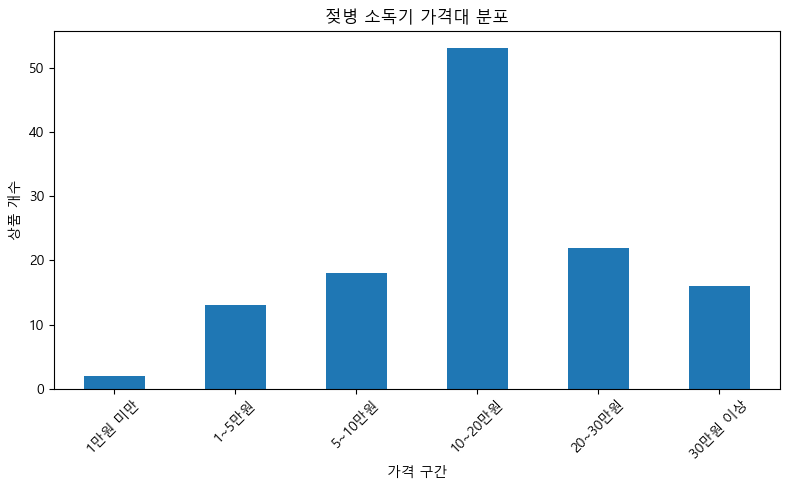

In [44]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 가격 숫자로 변환
df['price_num'] = df['price'].str.replace('원','').str.replace(',','').astype(int)

# 가격 구간 설정
bins = [0,10000,50000,100000,200000,300000,10000000]
labels = [
    '1만원 미만',
    '1~5만원',
    '5~10만원',
    '10~20만원',
    '20~30만원',
    '30만원 이상'
]

df['price_range'] = pd.cut(df['price_num'], bins=bins, labels=labels)

# 개수 집계
price_count = df['price_range'].value_counts().sort_index()

# 그래프
plt.figure(figsize=(8,5))
price_count.plot(kind='bar')

plt.title('젖병 소독기 가격대 분포')
plt.xlabel('가격 구간')
plt.ylabel('상품 개수')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [1]:
ProductUnit_productInfo__1l0il
ProductUnit_productInfo__1l0il

SyntaxError: invalid decimal literal (3751241676.py, line 1)